In [1]:
import xarray as xr

In [2]:
# Abrimos uno de los archivos descargados
ds = xr.open_dataset('../datos/RadFC_20240418180020.nc')
ds

<xarray.Dataset> Size: 17MB
Dimensions:  (y: 920, x: 920)
Dimensions without coordinates: y, x
Data variables:
    Rad8     (y, x) float32 3MB ...
    Rad9     (y, x) float32 3MB ...
    Rad10    (y, x) float32 3MB ...
    Rad13    (y, x) float32 3MB ...
    Rad14    (y, x) float32 3MB ...
    lat      (y) float64 7kB ...
    lon      (x) float64 7kB ...
Attributes:
    missing_rad:  []

In [3]:
ds['Rad13']

<xarray.DataArray 'Rad13' (y: 920, x: 920)> Size: 3MB
[846400 values with dtype=float32]
Dimensions without coordinates: y, x
Attributes:
    long_name:              ABI L1b Radiances
    standard_name:          toa_outgoing_radiance_per_unit_wavenumber
    sensor_band_bit_depth:  12
    valid_range:            [   0 4094]
    units:                  mW m-2 sr-1 (cm-1)-1
    resolution:             y: 0.000056 rad x: 0.000056 rad
    grid_mapping:           goes_imager_projection
    cell_methods:           t: point area: point
    ancillary_variables:    DQF

In [4]:
ds.attrs

{'missing_rad': array([], dtype=float64)}

In [7]:
#import GOES

GOES.download('goes16', 'ABI-L1b-RadF',
               DateTimeIni='20240418-180000', DateTimeFin='20240418-181000',
               channel=['13'], path_out='../datos/')

Files:
  OR_ABI-L1b-RadF-M6C13_G16_s20241091800203_e20241091809523_c20241091809567.nc 100% 26.1MB 7s


['../datos/OR_ABI-L1b-RadF-M6C13_G16_s20241091800203_e20241091809523_c20241091809567.nc']

In [8]:
ds_original = xr.open_dataset('../datos/OR_ABI-L1b-RadF-M6C13_G16_s20241091800203_e20241091809523_c20241091809567.nc')
ds_original.attrs

{'naming_authority': 'gov.nesdis.noaa',
 'Conventions': 'CF-1.7',
 'standard_name_vocabulary': 'CF Standard Name Table (v35, 20 July 2016)',
 'institution': 'DOC/NOAA/NESDIS > U.S. Department of Commerce, National Oceanic and Atmospheric Administration, National Environmental Satellite, Data, and Information Services',
 'project': 'GOES',
 'production_site': 'WCDAS',
 'production_environment': 'OE',
 'spatial_resolution': '2km at nadir',
 'Metadata_Conventions': 'Unidata Dataset Discovery v1.0',
 'orbital_slot': 'GOES-East',
 'platform_ID': 'G16',
 'instrument_type': 'GOES-R Series Advanced Baseline Imager (ABI)',
 'scene_id': 'Full Disk',
 'instrument_ID': 'FM1',
 'title': 'ABI L1b Radiances',
 'summary': 'Single emissive band ABI L1b Radiance Products are digital maps of outgoing radiance values at the top of the atmosphere for IR bands.',
 'keywords': 'SPECTRAL/ENGINEERING > INFRARED WAVELENGTHS > INFRARED RADIANCE',
 'keywords_vocabulary': 'NASA Global Change Master Directory (GCMD

In [9]:
ds_original['Rad'].attrs

{'long_name': 'ABI L1b Radiances',
 'standard_name': 'toa_outgoing_radiance_per_unit_wavenumber',
 'sensor_band_bit_depth': np.int8(12),
 'valid_range': array([   0, 4094], dtype=int16),
 'units': 'mW m-2 sr-1 (cm-1)-1',
 'resolution': 'y: 0.000056 rad x: 0.000056 rad',
 'grid_mapping': 'goes_imager_projection',
 'cell_methods': 't: point area: point',
 'ancillary_variables': 'DQF'}

In [11]:
fk1 = float(ds_original['planck_fk1'].values)
fk2 = float(ds_original['planck_fk2'].values)
bc1 = float(ds_original['planck_bc1'].values)
bc2 = float(ds_original['planck_bc2'].values)

print(fk1, fk2, bc1, bc2)

10803.2998046875 1392.739990234375 0.0754999965429306 0.999750018119812


In [ ]:
#import numpy as np

rad13 = ds['Rad13'].values

bt13 = (fk2 / np.log((fk1 / rad13) + 1) - bc1) / bc2  # en Kelvin

print('Min:', bt13.min(), 'K')
print('Max:', bt13.max(), 'K')
print('Media:', bt13.mean(), 'K')

Min: 186.65953 K
Max: 314.49826 K
Media: 262.02972 K


En el caso del 18 de abril de 2024, a las 18:00 UTC, la banda 13 registró temperaturas de brillo entre 186.7 K y 314.5 K sobre el área de estudio, con el mínimo consistente con un tope convectivo profundo coincidiendo con el inicio del evento de lluvia fuerte reportado en METAR.

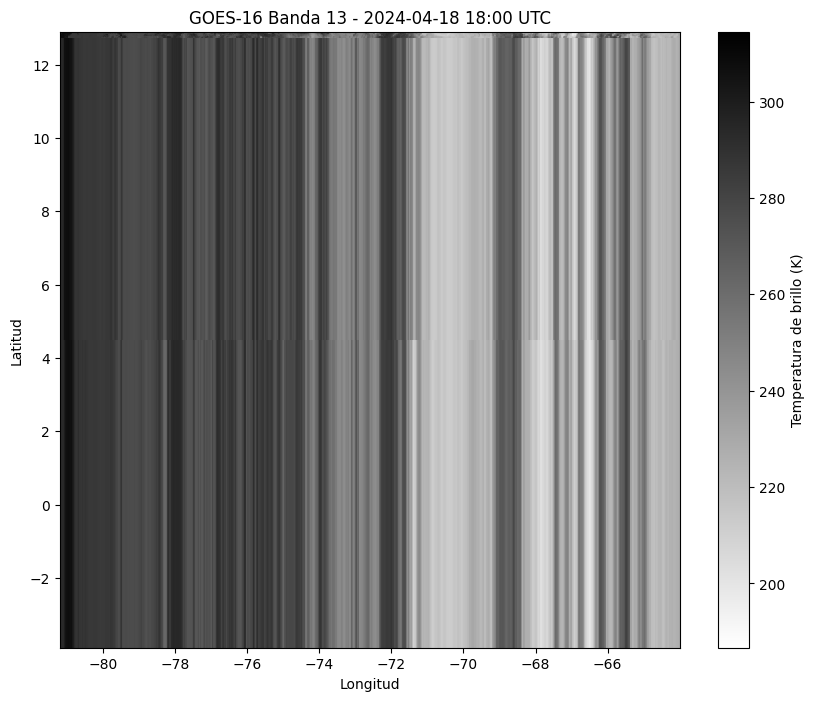

In [13]:
#import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.pcolormesh(ds['lon'], ds['lat'], bt13, cmap='gray_r', shading='auto')
plt.colorbar(label='Temperatura de brillo (K)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('GOES-16 Banda 13 - 2024-04-18 18:00 UTC')
plt.show()

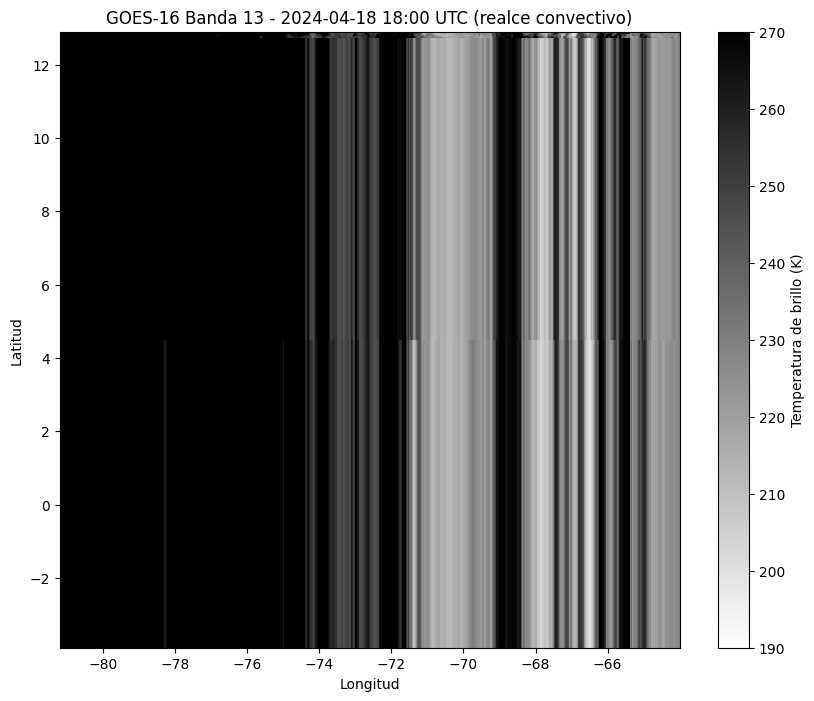

In [14]:
plt.figure(figsize=(10, 8))
plt.pcolormesh(ds['lon'], ds['lat'], bt13, cmap='gray_r', shading='auto', vmin=190, vmax=270)
plt.colorbar(label='Temperatura de brillo (K)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('GOES-16 Banda 13 - 2024-04-18 18:00 UTC (realce convectivo)')
plt.show()

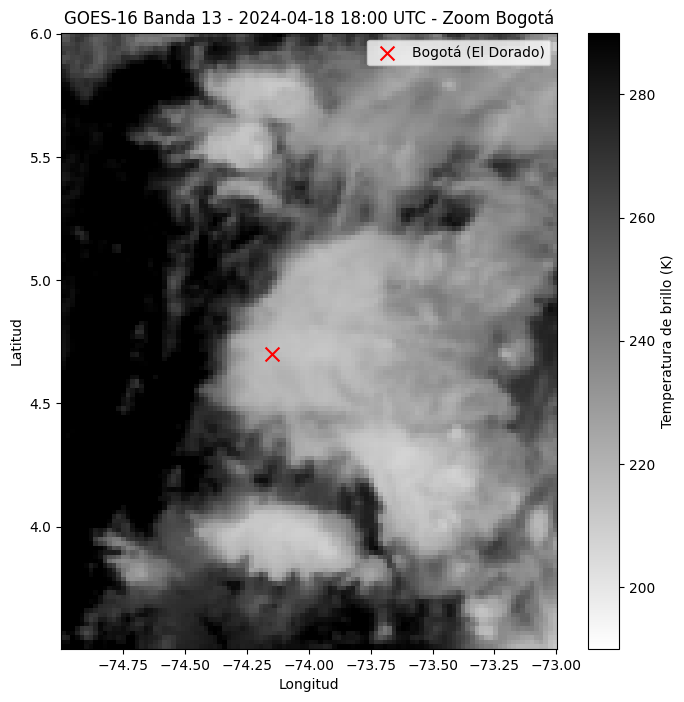

In [16]:
# Hacer zoom a la región de Bogotá
ds_bogota = ds.sel(x=slice(None), y=slice(None))  # placeholder, ajustamos abajo

# Encontrar los índices correspondientes a la región de Bogotá
lon_mask = (ds['lon'] >= -75) & (ds['lon'] <= -73)
lat_mask = (ds['lat'] >= 3.5) & (ds['lat'] <= 6)

lon_bog = ds['lon'][lon_mask]
lat_bog = ds['lat'][lat_mask]
bt13_bog = bt13[np.ix_(lat_mask.values, lon_mask.values)]

plt.figure(figsize=(8, 8))
plt.pcolormesh(lon_bog, lat_bog, bt13_bog, cmap='gray_r', shading='auto', vmin=190, vmax=290)
plt.colorbar(label='Temperatura de brillo (K)')
plt.scatter([-74.15], [4.70], color='red', marker='x', s=100, label='Bogotá (El Dorado)')
plt.legend()
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('GOES-16 Banda 13 - 2024-04-18 18:00 UTC - Zoom Bogotá')
plt.savefig('../resultados/banda13_tormenta_20240418_1800UTC.png', dpi=150, bbox_inches='tight')
plt.show()